# Iowa Liquor Sales Analysis  
### SKU Rationalization, Catalog Productivity, and Inventory Velocity

This analysis explores the productivity of the active product catalog in the Iowa liquor market using transaction-level data modeled in Snowflake and dbt.

The goal is to understand:
- how volume and revenue are distributed across the active SKU catalog (The Pareto Principle)
- which products form the "Core" assortment driving the vast majority of statewide sales  
- the operational impact of the "Long Tail" (Zombie SKUs) that consume physical shelf space and working capital with minimal return

In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

user = os.getenv("DBT_USER")
password = os.getenv("DBT_PASSWORD")
account = os.getenv("DBT_ACCOUNT")
warehouse = os.getenv("DBT_WAREHOUSE")
database = os.getenv("DBT_DATABASE")
schema = os.getenv("DBT_DEV_SCHEMA")

print(user, account, database, schema)

engine = create_engine(
    f"snowflake://{user}:{password}@{account}/{database}/{schema}?warehouse={warehouse}"
)

joelam STHKDLC-NRB37885 planning_os dev


In [3]:
import pandas as pd

pd.read_sql("select current_version()", engine)

,CURRENT_VERSION()
0,10.10.2


In [14]:
query = """
select
    sku_tier_volume as sku_tier,
    count(*) as sku_count,
    sum(total_units_sold) as units_sold,
    sum(total_revenue) as revenue,
    count(*) / nullif(max(active_sku_count), 0)::float as pct_of_catalog,
    sum(total_units_sold) / nullif(max(state_total_units), 0)::float as pct_of_volume,
    sum(total_revenue) / nullif(max(state_total_revenue), 0)::float as pct_of_revenue
from fct_sku_velocity
group by sku_tier_volume
order by sku_tier_volume
"""

df_sku_velocity = pd.read_sql(query, engine)

df_sku_velocity

,sku_tier,sku_count,units_sold,revenue,pct_of_catalog,pct_of_volume,pct_of_revenue
0,Tier 1: Core (Top 80% Volume),469,6044989,79064385.80,0.143953,0.799742,0.738151
1,Tier 2: Niche (Next 15% Volume),818,1135235,18497839.22,0.251074,0.150190,0.172697
2,Tier 3: Zombie (Bottom 5% Volume),1971,378447,9549211.82,0.604972,0.050068,0.089152


In [15]:
rev_query = """
select
    sku_tier_revenue as sku_tier,
    count(*) as sku_count,
    sum(total_units_sold) as units_sold,
    sum(total_revenue) as revenue,
    count(*) / nullif(max(active_sku_count), 0)::float as pct_of_catalog,
    sum(total_units_sold) / nullif(max(state_total_units), 0)::float as pct_of_volume,
    sum(total_revenue) / nullif(max(state_total_revenue), 0)::float as pct_of_revenue
from fct_sku_velocity
group by sku_tier_revenue
order by sku_tier_revenue
"""
rev_df = pd.read_sql(rev_query, engine)

tier_order_rev = [
    "Tier 1: Core (Top 80% Revenue)",
    "Tier 2: Niche (Next 15% Revenue)",
    "Tier 3: Zombie (Bottom 5% Revenue)"
]
rev_df["sku_tier"] = pd.Categorical(rev_df["sku_tier"], categories=tier_order_rev, ordered=True)
rev_df = rev_df.sort_values("sku_tier")
rev_df["pct_catalog"] = rev_df["pct_of_catalog"] * 100
rev_df["pct_revenue"] = rev_df["pct_of_revenue"] * 100

df_sku_velocity_rev = pd.read_sql(rev_query, engine)

df_sku_velocity_rev

,sku_tier,sku_count,units_sold,revenue,pct_of_catalog,pct_of_volume,pct_of_revenue
0,Tier 1: Core (Top 80% Revenue),534,5909455,85665293.89,0.163904,0.781811,0.799777
1,Tier 2: Niche (Next 15% Revenue),924,1225376,16088166.54,0.283610,0.162115,0.150200
2,Tier 3: Zombie (Bottom 5% Revenue),1800,423840,5357976.41,0.552486,0.056073,0.050022


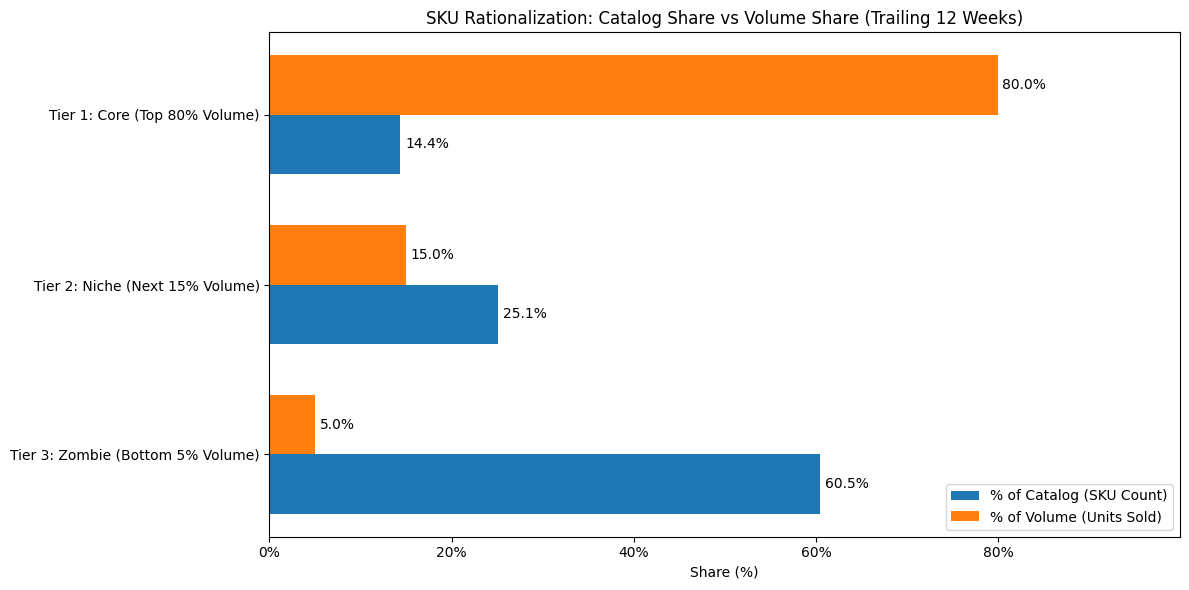

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# Ensure tier order is stable
tier_order = [
    "Tier 1: Core (Top 80% Volume)",
    "Tier 2: Niche (Next 15% Volume)",
    "Tier 3: Zombie (Bottom 5% Volume)"
]

plot_df = df_sku_velocity.copy()
plot_df["sku_tier"] = pd.Categorical(plot_df["sku_tier"], categories=tier_order, ordered=True)
plot_df = plot_df.sort_values("sku_tier")

# Convert to percentages for chart readability
plot_df["pct_catalog"] = plot_df["pct_of_catalog"] * 100
plot_df["pct_volume"] = plot_df["pct_of_volume"] * 100
plot_df["pct_revenue"] = plot_df["pct_of_revenue"] * 100

y = np.arange(len(plot_df))
bar_h = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars_catalog = ax.barh(y + bar_h/2, plot_df["pct_catalog"], height=bar_h, label="% of Catalog (SKU Count)")
bars_volume  = ax.barh(y - bar_h/2, plot_df["pct_volume"],  height=bar_h, label="% of Volume (Units Sold)")

ax.set_yticks(y)
ax.set_yticklabels(plot_df["sku_tier"])
ax.invert_yaxis()  # Tier 1 at top, Tier 3 at bottom
ax.set_xlabel("Share (%)")
ax.set_title("SKU Rationalization: Catalog Share vs Volume Share (Trailing 12 Weeks)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, max(plot_df["pct_catalog"].max(), plot_df["pct_volume"].max()) * 1.25)
ax.legend(loc="lower right")

# Add labels
for b in bars_catalog:
    w = b.get_width()
    ax.text(w + 0.5, b.get_y() + b.get_height()/2, f"{w:.1f}%", va="center")
for b in bars_volume:
    w = b.get_width()
    ax.text(w + 0.5, b.get_y() + b.get_height()/2, f"{w:.1f}%", va="center")

plt.tight_layout()
plt.show()

In [17]:
core = plot_df.loc[plot_df["sku_tier"] == "Tier 1: Core (Top 80% Volume)"].iloc[0]
zombie = plot_df.loc[plot_df["sku_tier"] == "Tier 3: Zombie (Bottom 5% Volume)"].iloc[0]

print(
    f"The Zombie Tax: {zombie['pct_catalog']:.1f}% of active SKUs drive only "
    f"{zombie['pct_volume']:.1f}% of volume, while the Core {core['pct_catalog']:.1f}% drives "
    f"{core['pct_volume']:.1f}%."
)

The Zombie Tax: 60.5% of active SKUs drive only 5.0% of volume, while the Core 14.4% drives 80.0%.


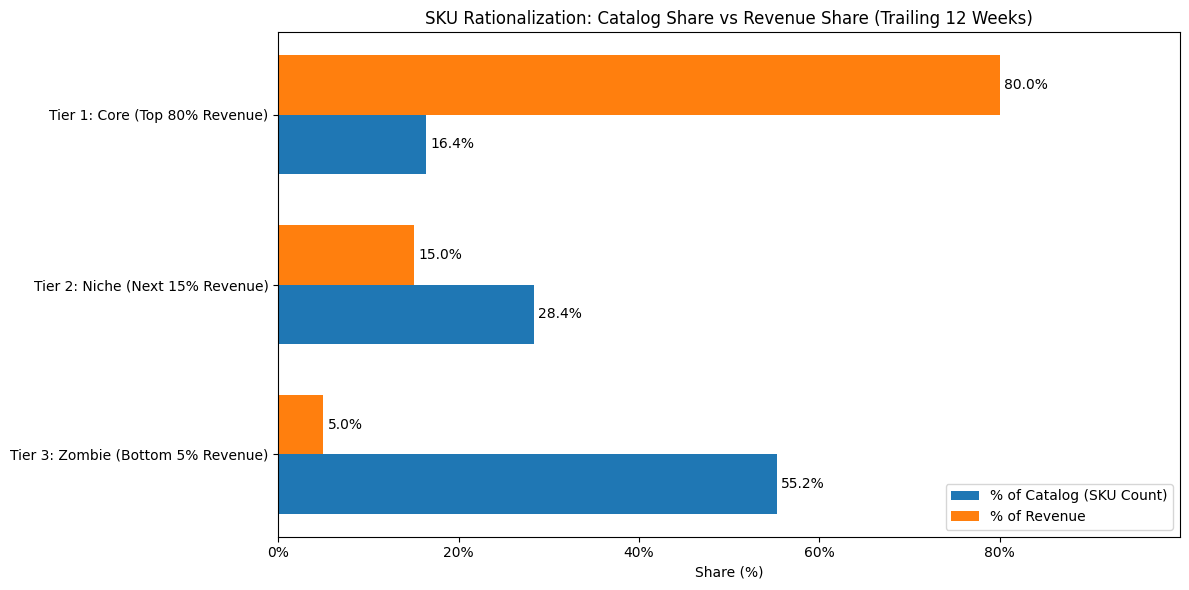

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

y = np.arange(len(rev_df))
bar_h = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars_catalog = ax.barh(
    y + bar_h/2,
    rev_df["pct_catalog"],
    height=bar_h,
    label="% of Catalog (SKU Count)"
)
bars_revenue = ax.barh(
    y - bar_h/2,
    rev_df["pct_revenue"],
    height=bar_h,
    label="% of Revenue"
)

ax.set_yticks(y)
ax.set_yticklabels(rev_df["sku_tier"])
ax.invert_yaxis()
ax.set_xlabel("Share (%)")
ax.set_title("SKU Rationalization: Catalog Share vs Revenue Share (Trailing 12 Weeks)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, max(rev_df["pct_catalog"].max(), rev_df["pct_revenue"].max()) * 1.25)
ax.legend(loc="lower right")

for b in bars_catalog:
    w = b.get_width()
    ax.text(w + 0.5, b.get_y() + b.get_height()/2, f"{w:.1f}%", va="center")
for b in bars_revenue:
    w = b.get_width()
    ax.text(w + 0.5, b.get_y() + b.get_height()/2, f"{w:.1f}%", va="center")

plt.tight_layout()
plt.show()

In [19]:
core_rev = rev_df.loc[rev_df["sku_tier"] == "Tier 1: Core (Top 80% Revenue)"].iloc[0]
zombie_rev = rev_df.loc[rev_df["sku_tier"] == "Tier 3: Zombie (Bottom 5% Revenue)"].iloc[0]

print(
    f"The Zombie Tax (Revenue): {zombie_rev['pct_catalog']:.1f}% of active SKUs generate only "
    f"{zombie_rev['pct_revenue']:.1f}% of revenue, while the Core {core_rev['pct_catalog']:.1f}% drives "
    f"{core_rev['pct_revenue']:.1f}%."
)

The Zombie Tax (Revenue): 55.2% of active SKUs generate only 5.0% of revenue, while the Core 16.4% drives 80.0%.
